
# 07_multimodal_business_intelligence.ipynb

## Enterprise Multimodal Business Intelligence Layer

This notebook converts the multimodal feature store into:
- executive business intelligence
- catalog analytics
- product quality dashboards
- retrieval intelligence analytics
- duplicate forensics
- color/style trend intelligence

---

## Intelligence Layers

### Catalog Intelligence
- product quality analytics
- media richness analysis
- retrieval quality analysis

### Commerce Intelligence
- color trends
- style trends
- logo analytics
- duplicate risk analysis

### Executive Intelligence
- top products
- unhealthy catalog segments
- enterprise scoring
- operational insights

### Final Outputs
- BI tables
- dashboard datasets
- executive summaries
- trend analytics


In [1]:

!pip install -q pyarrow


In [2]:

import os
import json
import warnings

import numpy as np
import pandas as pd

from collections import Counter
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)


In [3]:

BASE_DIR = "/kaggle/working"

BI_DIR = (
    f"{BASE_DIR}/business_intelligence_layer"
)

os.makedirs(
    BI_DIR,
    exist_ok=True
)

print(BI_DIR)


/kaggle/working/business_intelligence_layer



# Stage 1 — Load Enterprise Feature Store


In [4]:

product_df = pd.read_parquet(

    "/kaggle/input/notebooks/hanafudaearring/multimodal-feature-store/multimodal_feature_store/enterprise_product_feature_store.parquet"
)

retrieval_df = pd.read_parquet(

    "/kaggle/input/notebooks/hanafudaearring/multimodal-feature-store/multimodal_feature_store/retrieval_feature_store.parquet"
)

print(
    "PRODUCT DF:",
    product_df.shape
)

print(
    "RETRIEVAL DF:",
    retrieval_df.shape
)


PRODUCT DF: (728, 23)
RETRIEVAL DF: (728, 7)


In [5]:

product_df.head()


,asin,image_count,avg_quality_score,avg_embedding_health,avg_media_score,duplicate_ratio,color_diversity,style_diversity,logo_density,dominant_color,dominant_visual_category,top_styles,detected_logos,merged_caption,visual_uniqueness,fused_embedding,product_intelligence_score,foreground_color,catalog_health_score,retrieval_quality_score,duplicate_risk,semantic_richness,enterprise_product_score
0,B00021NY28,6,0.356888,0.595175,0.462246,0.0,3,0,0.000000,white,unknown,[],[],a woman in a white top and black pants | a wom...,NaN,"[0.017875921, 0.02697452, -0.032951687, -0.005...",0.603577,unknown,0.420660,0.988417,low,3.000000,1.469692
1,B0006U6C0Q,7,0.331323,0.622507,0.490208,0.0,4,0,0.000000,white,unknown,[],[],a man in a blue shirt and jeans | a man in a b...,NaN,"[0.014319795, 0.020532222, -0.022347748, -0.00...",0.611010,unknown,0.471241,0.989680,low,4.000000,1.820307
2,B0007CKJSY,7,0.287760,0.616898,0.508821,0.0,4,0,0.000000,white,unknown,[],[],wr men ' s wr wr wr wr wr wr wr wr wr wr wr wr...,NaN,"[0.0085501205, 0.01536036, -0.01711279, -0.010...",0.603370,unknown,0.443865,0.988481,low,4.000000,1.810782
3,B0008EOG9E,3,0.384456,0.573370,0.403791,1.0,2,0,0.666667,white,unknown,[],[],"levi levi men ' s regular fit jeans, blue, 34w...",NaN,"[0.0031577311, 0.022369334, -0.0078112525, 0.0...",0.340404,unknown,0.355698,0.978450,high,2.666667,1.333605
4,B0008EOGAS,3,0.384456,0.576210,0.404737,1.0,2,0,0.666667,white,unknown,[],[],"levi levi men ' s regular fit jeans, blue, 34w...",NaN,"[0.008239375, 0.020316346, -0.0069890865, 0.01...",0.341351,unknown,0.357776,0.982514,high,2.666667,1.335652



# Stage 2 — Executive Catalog KPIs


In [6]:

executive_kpis = {

    "total_products":
        int(len(product_df)),

    "avg_catalog_health":
        float(
            product_df[
                "catalog_health_score"
            ].mean()
        ),

    "avg_retrieval_quality":
        float(
            product_df[
                "retrieval_quality_score"
            ].mean()
        ),

    "high_duplicate_risk_products":
        int(
            (
                product_df[
                    "duplicate_risk"
                ] == "high"
            ).sum()
        ),

    "products_with_logos":
        int(
            (
                product_df[
                    "logo_density"
                ] > 0
            ).sum()
        ),

    "unique_foreground_colors":
        int(
            product_df[
                "foreground_color"
            ].nunique()
        )
}

executive_kpis


{'total_products': 728,
 'avg_catalog_health': 0.4157034303028814,
 'avg_retrieval_quality': 0.9818079201402244,
 'high_duplicate_risk_products': 32,
 'products_with_logos': 58,
 'unique_foreground_colors': 7}


# Stage 3 — Catalog Health Analytics


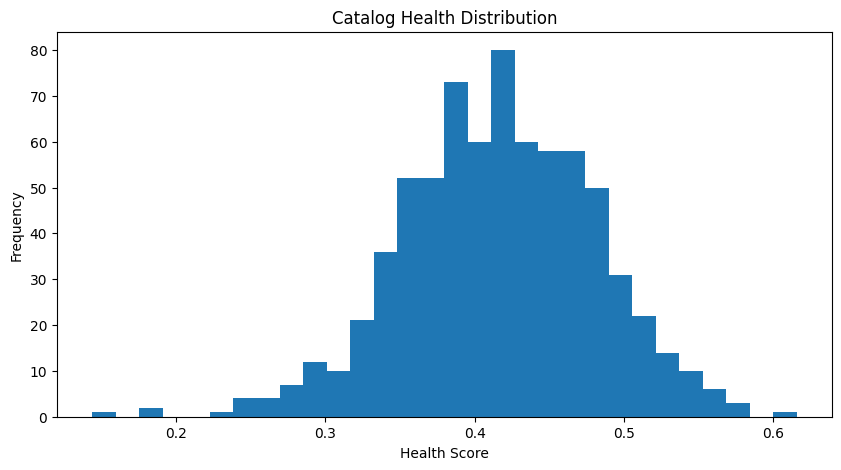

In [7]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "catalog_health_score"
    ],

    bins=30
)

plt.title(
    "Catalog Health Distribution"
)

plt.xlabel("Health Score")
plt.ylabel("Frequency")

plt.show()


In [8]:

health_segments = pd.cut(

    product_df[
        "catalog_health_score"
    ],

    bins=[0,0.3,0.45,1.0],

    labels=[
        "low",
        "medium",
        "high"
    ]
)

health_distribution = (
    health_segments
    .value_counts()
)

health_distribution


catalog_health_score
medium    478
high      219
low        31
Name: count, dtype: int64


# Stage 4 — Retrieval Intelligence Analytics


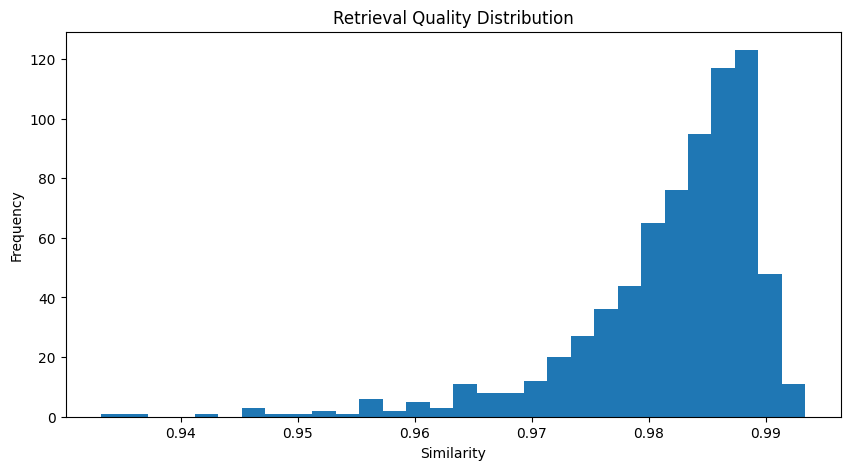

In [9]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "retrieval_quality_score"
    ],

    bins=30
)

plt.title(
    "Retrieval Quality Distribution"
)

plt.xlabel("Similarity")
plt.ylabel("Frequency")

plt.show()


In [10]:

retrieval_leaders = product_df.sort_values(

    "retrieval_quality_score",

    ascending=False
)[[

    "asin",

    "retrieval_quality_score",

    "catalog_health_score",

    "foreground_color"
]].head(20)

retrieval_leaders


,asin,retrieval_quality_score,catalog_health_score,foreground_color
437,B0B713424T,0.993370,0.423009,black
388,B09QRMVL84,0.992850,0.448983,black
442,B0B883C9XX,0.992479,0.457487,unknown
418,B0B34QD8XV,0.992097,0.450095,black
642,B0D59TM92S,0.991975,0.454296,unknown
421,B0B34WQ6L2,0.991833,0.444185,black
313,B08P52ZV47,0.991817,0.496866,unknown
601,B0CRRF28SH,0.991647,0.522930,pink
139,B0792XJHZL,0.991639,0.459331,unknown
237,B07YHG62J6,0.991584,0.383421,black



# Stage 5 — Duplicate Forensics


In [11]:

duplicate_distribution = (
    product_df[
        "duplicate_risk"
    ]
    .value_counts()
)

duplicate_distribution


duplicate_risk
low       667
high       32
medium     29
Name: count, dtype: int64

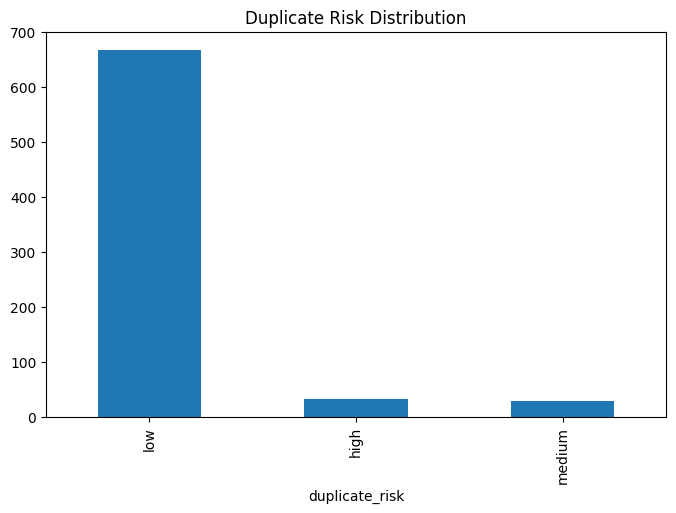

In [12]:

duplicate_distribution.plot.bar(
    figsize=(8,5)
)

plt.title(
    "Duplicate Risk Distribution"
)

plt.show()


In [13]:

high_duplicate_products = product_df[

    product_df[
        "duplicate_risk"
    ] == "high"
][[

    "asin",

    "duplicate_ratio",

    "catalog_health_score",

    "foreground_color"
]]

high_duplicate_products.head(20)


,asin,duplicate_ratio,catalog_health_score,foreground_color
3,B0008EOG9E,1.0,0.355698,unknown
4,B0008EOGAS,1.0,0.357776,unknown
52,B01BDZMIK0,1.0,0.373815,black
53,B01BDZMRR4,1.0,0.371643,black
64,B01GH5KNR6,1.0,0.433686,unknown
65,B01GH5KOZ2,1.0,0.431921,unknown
158,B07DRMT92L,1.0,0.429508,pink
159,B07DRN7QQD,1.0,0.429882,pink
163,B07FMX9FSF,1.0,0.322178,unknown
167,B07FMZ12CJ,1.0,0.324961,unknown



# Stage 6 — Color Intelligence Analytics


In [14]:

color_distribution = (
    product_df[
        "foreground_color"
    ]
    .value_counts()
)

color_distribution


foreground_color
unknown    501
black      103
pink        99
brown       19
green        3
orange       2
purple       1
Name: count, dtype: int64

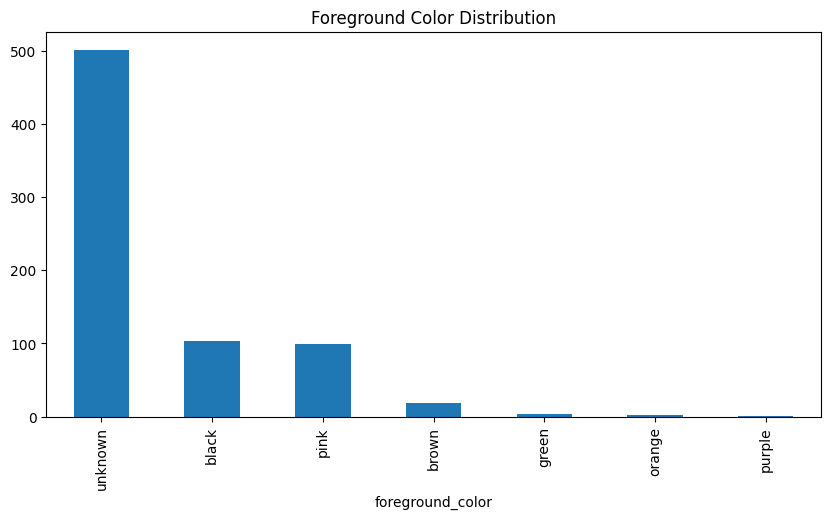

In [15]:

color_distribution.plot.bar(
    figsize=(10,5)
)

plt.title(
    "Foreground Color Distribution"
)

plt.show()


In [16]:

color_health = product_df.groupby(

    "foreground_color"

).agg({

    "catalog_health_score": "mean",

    "retrieval_quality_score": "mean",

    "asin": "count"
}).rename(columns={

    "asin": "product_count"
})

color_health


,catalog_health_score,retrieval_quality_score,product_count
foreground_color,,,
black,0.423880,0.983191,103
brown,0.413276,0.976649,19
green,0.372968,0.974839,3
orange,0.327914,0.960981,2
pink,0.423357,0.980947,99
purple,0.525964,0.990434,1
unknown,0.412988,0.981997,501



# Stage 7 — Semantic Richness Intelligence


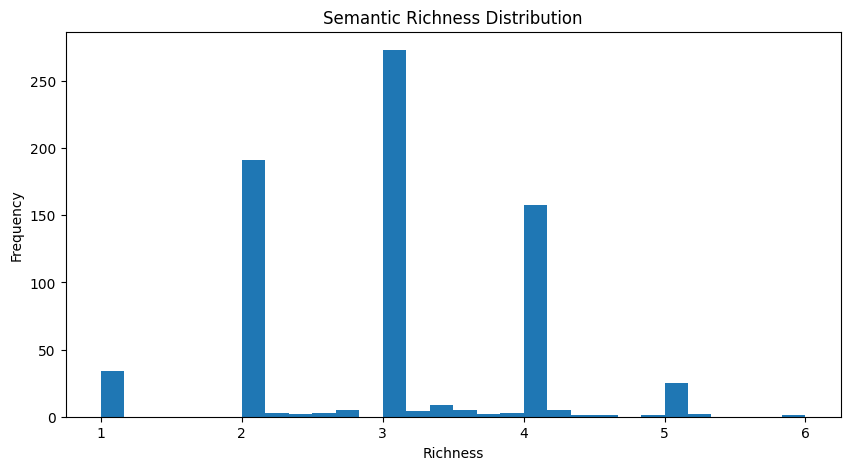

In [17]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "semantic_richness"
    ],

    bins=30
)

plt.title(
    "Semantic Richness Distribution"
)

plt.xlabel("Richness")
plt.ylabel("Frequency")

plt.show()


In [18]:

semantic_leaders = product_df.sort_values(

    "semantic_richness",

    ascending=False
)[[

    "asin",

    "semantic_richness",

    "foreground_color",

    "catalog_health_score"
]].head(20)

semantic_leaders


,asin,semantic_richness,foreground_color,catalog_health_score
620,B0CY29F6G4,6.000000,unknown,0.550143
347,B098KXZG2Z,5.166667,purple,0.525964
714,B0DRXCWRYM,5.166667,black,0.505914
678,B0DFBDPKV8,5.000000,brown,0.444472
637,B0D4DXQBF1,5.000000,unknown,0.463276
721,B0DSW6C8PT,5.000000,unknown,0.532716
724,B0DWXNDJPK,5.000000,pink,0.505941
528,B0C72M9R32,5.000000,unknown,0.474622
504,B0BZ76N2MX,5.000000,unknown,0.477600
94,B06VZ3RCYS,5.000000,black,0.561966



# Stage 8 — Enterprise Product Intelligence


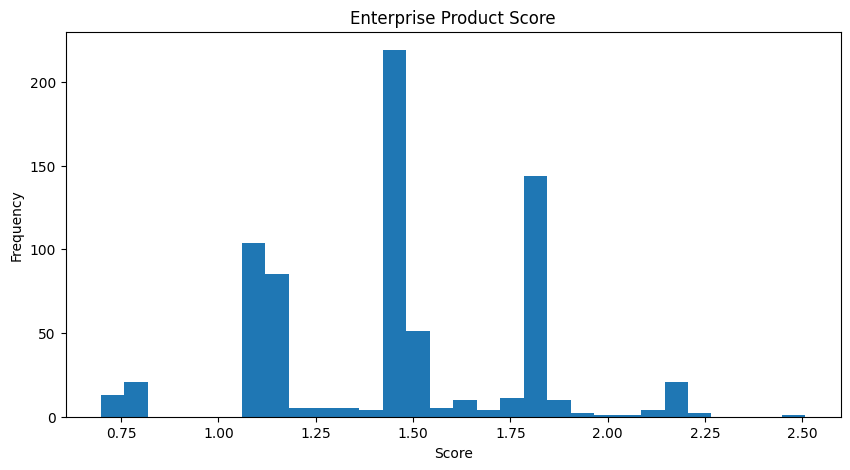

In [19]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "enterprise_product_score"
    ],

    bins=30
)

plt.title(
    "Enterprise Product Score"
)

plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()


In [20]:

top_enterprise_products = product_df.sort_values(

    "enterprise_product_score",

    ascending=False
)[[

    "asin",

    "enterprise_product_score",

    "foreground_color",

    "catalog_health_score",

    "retrieval_quality_score"
]].head(25)

top_enterprise_products


,asin,enterprise_product_score,foreground_color,catalog_health_score,retrieval_quality_score
620,B0CY29F6G4,2.508264,unknown,0.550143,0.974651
347,B098KXZG2Z,2.227688,purple,0.525964,0.990434
714,B0DRXCWRYM,2.220622,black,0.505914,0.989287
256,B085NF55WL,2.188983,unknown,0.579785,0.987163
94,B06VZ3RCYS,2.183557,black,0.561966,0.988704
125,B077SVB38N,2.182869,pink,0.560893,0.987716
234,B07VTSD48H,2.180450,pink,0.554615,0.986734
328,B08Z755PCH,2.178966,unknown,0.560695,0.976203
721,B0DSW6C8PT,2.171436,unknown,0.532716,0.981592
449,B0BGSDG377,2.171188,unknown,0.523684,0.989881



# Stage 9 — Product Diversity Intelligence


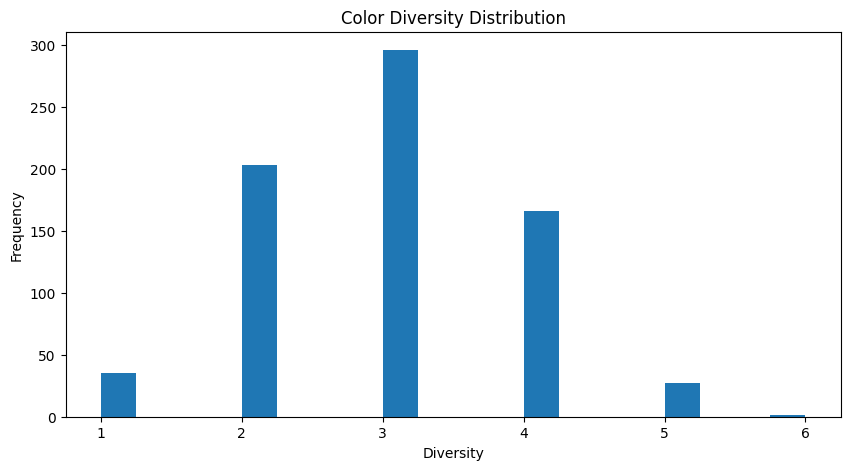

In [21]:

plt.figure(figsize=(10,5))

plt.hist(

    product_df[
        "color_diversity"
    ],

    bins=20
)

plt.title(
    "Color Diversity Distribution"
)

plt.xlabel("Diversity")
plt.ylabel("Frequency")

plt.show()


In [22]:

diversity_leaders = product_df.sort_values(

    "color_diversity",

    ascending=False
)[[

    "asin",

    "color_diversity",

    "semantic_richness",

    "catalog_health_score"
]].head(20)

diversity_leaders


,asin,color_diversity,semantic_richness,catalog_health_score
620,B0CY29F6G4,6,6.000000,0.550143
151,B07BN52FT6,5,5.000000,0.464717
396,B09VBK13ZV,5,5.000000,0.524911
637,B0D4DXQBF1,5,5.000000,0.463276
504,B0BZ76N2MX,5,5.000000,0.477600
94,B06VZ3RCYS,5,5.000000,0.561966
714,B0DRXCWRYM,5,5.166667,0.505914
718,B0DSBXZY87,5,5.000000,0.510960
256,B085NF55WL,5,5.000000,0.579785
678,B0DFBDPKV8,5,5.000000,0.444472



# Stage 10 — Brand / Logo Intelligence


In [23]:

logo_products = product_df[

    product_df[
        "logo_density"
    ] > 0
]

print(
    "PRODUCTS WITH LOGOS:",
    len(logo_products)
)

logo_products[[
    "asin",

    "logo_density",

    "foreground_color"
]].head(20)


PRODUCTS WITH LOGOS: 58


,asin,logo_density,foreground_color
3,B0008EOG9E,0.666667,unknown
4,B0008EOGAS,0.666667,unknown
8,B000W93PX8,0.142857,unknown
9,B0018OMIOI,0.333333,unknown
10,B0018ON68A,0.600000,unknown
39,B00UV3TGUG,0.400000,unknown
67,B01H7ENCLA,0.142857,unknown
70,B01IR7TZWG,0.600000,unknown
71,B01ISMKS7G,0.400000,unknown
81,B01M2ZRGN4,0.142857,unknown



# Stage 11 — Executive Dashboard Tables


In [24]:

executive_dashboard = pd.DataFrame([

    executive_kpis
])

executive_dashboard


,total_products,avg_catalog_health,avg_retrieval_quality,high_duplicate_risk_products,products_with_logos,unique_foreground_colors
0,728,0.415703,0.981808,32,58,7


In [25]:

category_dashboard = product_df.groupby(

    "dominant_visual_category"

).agg({

    "catalog_health_score": "mean",

    "retrieval_quality_score": "mean",

    "enterprise_product_score": "mean",

    "asin": "count"
}).rename(columns={

    "asin": "product_count"
})

category_dashboard


,catalog_health_score,retrieval_quality_score,enterprise_product_score,product_count
dominant_visual_category,,,,
unknown,0.415703,0.981808,1.453845,728


In [26]:

color_dashboard = product_df.groupby(

    "foreground_color"

).agg({

    "catalog_health_score": "mean",

    "enterprise_product_score": "mean",

    "asin": "count"
}).rename(columns={

    "asin": "product_count"
})

color_dashboard


,catalog_health_score,enterprise_product_score,product_count
foreground_color,,,
black,0.423880,1.490291,103
brown,0.413276,1.498396,19
green,0.372968,1.560380,3
orange,0.327914,1.596298,2
pink,0.423357,1.496159,99
purple,0.525964,2.227688,1
unknown,0.412988,1.433550,501



# Stage 12 — Enterprise BI Exports


In [27]:

executive_dashboard.to_parquet(

    f"{BI_DIR}/executive_dashboard.parquet",

    index=False
)

category_dashboard.to_parquet(

    f"{BI_DIR}/category_dashboard.parquet"
)

color_dashboard.to_parquet(

    f"{BI_DIR}/color_dashboard.parquet"
)

print(
    "EXPORTED DASHBOARD TABLES"
)


EXPORTED DASHBOARD TABLES


In [28]:

top_enterprise_products.to_parquet(

    f"{BI_DIR}/top_enterprise_products.parquet",

    index=False
)

retrieval_leaders.to_parquet(

    f"{BI_DIR}/retrieval_leaders.parquet",

    index=False
)

high_duplicate_products.to_parquet(

    f"{BI_DIR}/high_duplicate_products.parquet",

    index=False
)

print(
    "EXPORTED ANALYTICS TABLES"
)


EXPORTED ANALYTICS TABLES



# Stage 13 — Final Executive Report


In [29]:

final_report = {

    "total_products":
        int(len(product_df)),

    "avg_catalog_health":
        float(
            product_df[
                "catalog_health_score"
            ].mean()
        ),

    "avg_enterprise_score":
        float(
            product_df[
                "enterprise_product_score"
            ].mean()
        ),

    "high_duplicate_risk_products":
        int(
            (
                product_df[
                    "duplicate_risk"
                ] == "high"
            ).sum()
        ),

    "retrieval_quality_mean":
        float(
            product_df[
                "retrieval_quality_score"
            ].mean()
        ),

    "semantic_richness_mean":
        float(
            product_df[
                "semantic_richness"
            ].mean()
        )
}

final_report


{'total_products': 728,
 'avg_catalog_health': 0.4157034303028814,
 'avg_enterprise_score': 1.453845140536678,
 'high_duplicate_risk_products': 32,
 'retrieval_quality_mean': 0.9818079201402244,
 'semantic_richness_mean': 2.9640240711669277}

In [30]:

with open(

    f"{BI_DIR}/executive_report.json",

    "w"

) as f:

    json.dump(
        final_report,
        f,
        indent=4
    )

print("=" * 60)

print(
    "MULTIMODAL BUSINESS INTELLIGENCE COMPLETE"
)

print("=" * 60)

print(
    "TOTAL PRODUCTS:",
    len(product_df)
)

print(
    "AVG CATALOG HEALTH:",
    round(
        product_df[
            "catalog_health_score"
        ].mean(),
        4
    )
)

print(
    "AVG RETRIEVAL QUALITY:",
    round(
        product_df[
            "retrieval_quality_score"
        ].mean(),
        4
    )
)

print("=" * 60)


MULTIMODAL BUSINESS INTELLIGENCE COMPLETE
TOTAL PRODUCTS: 728
AVG CATALOG HEALTH: 0.4157
AVG RETRIEVAL QUALITY: 0.9818
